In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [3]:
train_df = pd.read_csv("./data/bank_app_reviews_train.csv")
train_df.head()

,리뷰일,평점,사용자리뷰,업체답변,은행명
0,2023-12-21,5,엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 ㅎㅎ 저도 쓰고있음!,NaN,하나
1,2025-02-17,1,Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...,안녕하세요. 신한은행입니다.\n먼저 SOL사용에 불편을 드려 죄송합니다.\n어플의 ...,신한
2,2024-07-26,5,서비스가 통합되어 있어서 점점 사용빈도가 높아지네요.,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민
3,2024-09-01,1,카드 충천이 안됌,"안녕하세요. 전민구 님, 토스팀입니다. 남겨주신 내용만으로는 겪고계신 불편사항의 자...",토스
4,2023-11-13,1,알뜰폰 인증이 안돼요.....,"안녕하세요 헤이모두들안녕님, 우리은행입니다. 먼저 이용에 불편을 드려 매우 죄송합니...",우리


In [4]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22246 entries, 0 to 22245
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   리뷰일     22246 non-null  str  
 1   평점      22246 non-null  int64
 2   사용자리뷰   22246 non-null  str  
 3   업체답변    19141 non-null  str  
 4   은행명     22246 non-null  str  
dtypes: int64(1), str(4)
memory usage: 869.1 KB


In [5]:
test_df = pd.read_csv("./data/bank_app_reviews_test.csv")
test_df.head()

,리뷰일,평점,사용자리뷰,업체답변,은행명
0,2024-02-08,5,고경민계장님감사해요,"안녕하세요 최순녀 고객님. 칭찬 진심으로 감사드리며, 더욱 편리하고 안정적인 서비스...",우리
1,2023-07-24,5,저축목표피드 새로 생긴거 너무좋은데 분명 카테고리를 저축으로 했는데 왜 인식이 안되...,"신아​ 님, 안녕하세요? 뱅크샐러드 고객감동팀​입니다. 소중한 시간내어 고객센터에 ...",뱅크샐러드
2,2023-09-25,1,아니 이딴걸 편리하게 사용하는앱이라고 쳐만들엇나 이렇게 불편하게만든건 일부러그런거에...,안녕하세요. 우리은행입니다. 먼저 우리WON뱅킹 이용에 불편을 드려 죄송합니다. 보...,우리
3,2024-02-15,3,몇 년째 만족하며 사용중이라 조금식 개선되어거는 모습에 만족하며 사용중입니다. 하지...,안녕하세요? 뱅크샐러드 고객감동팀입니다. 뱅크샐러드에 KB pay를 연결해 모든 자...,뱅크샐러드
4,2023-06-19,5,스타뱅킹을 사용 하고나서부터 편안해서 좋아요,"한송림 고객님, 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. 앞...",국민


In [6]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9534 entries, 0 to 9533
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   리뷰일     9534 non-null   str  
 1   평점      9534 non-null   int64
 2   사용자리뷰   9534 non-null   str  
 3   업체답변    8221 non-null   str  
 4   은행명     9534 non-null   str  
dtypes: int64(1), str(4)
memory usage: 372.6 KB


In [7]:
train_df['평점'].value_counts()

평점
5    11416
1     6751
4     1824
3     1308
2      947
Name: count, dtype: int64

In [8]:
train_df[train_df['평점'] == 5]

,리뷰일,평점,사용자리뷰,업체답변,은행명
0,2023-12-21,5,엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 ㅎㅎ 저도 쓰고있음!,NaN,하나
2,2024-07-26,5,서비스가 통합되어 있어서 점점 사용빈도가 높아지네요.,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민
7,2024-04-15,5,알아듣게 잘 이용 가입했어요,"안녕하세요 Jinhee Joo 고객님, 우리은행 우리WON뱅킹을 이용해주셔서 감사합...",우리
12,2024-05-30,5,편리합니다,"안녕하세요 마마초록 고객님. 칭찬 진심으로 감사드리며, 더욱 편리하고 안정적인 서비...",우리
15,2024-03-08,5,굿,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민
...,...,...,...,...,...
22236,2023-07-22,5,환전신청 편해요,"Ji K 고객님, 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. ...",국민
22239,2023-10-16,5,시스템 이용에 관한 설명이 잘 되어 있어 쉽게 일 처리할 수 있었습니다,"올리도라 고객님, 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사합니다. 앞...",국민
22240,2023-06-09,5,친절하고 상냥해요,Jin seog Kang 고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 ...,국민
22243,2023-07-07,5,굳굳굳,"Seung Woo Kim 고객님, 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로...",국민


In [9]:
train_df[train_df['평점'] == 4]

,리뷰일,평점,사용자리뷰,업체답변,은행명
11,2023-10-11,4,좋아요,NaN,토스
14,2023-11-21,4,좋음,"안녕하세요. 권유진 고객님, 우리은행입니다. 칭찬 진심으로 감사드리며, 더욱 편리하...",우리
27,2024-05-07,4,Not Found 실행이 안됩니다 하나은행 어플 누르면 Not Found 메세지 뜨...,안녕하세요. 하나은행입니다. 우선 이용에 불편을 드려 대단히 죄송합니다. 5/7일 ...,하나
30,2023-08-04,4,이전거보다 메뉴가 많아진건지 내가 사용하는게 걷기가 숨겨져 불편.확인 할때마다 일상...,"고객님, 안녕하세요! 7.26일 개편된 홈화면은 고객의견, 유저테스트 등 다양한 결...",국민
38,2025-04-04,4,보상을 얻기위해 광고를 보는건 상관없는데 광고 좀 가려 받으면 안되나요?,"안녕하세요. 성은하님, 토스팀입니다. 사용에 불편을 드려 죄송합니다. 다만, 남겨주...",토스
...,...,...,...,...,...
22171,2023-09-14,4,정확하고 친절하고 사용하기 좋네요,"CHIPO 고객님, 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사합니다. ...",국민
22204,2023-11-29,4,너무 잘쓰고있어요.한가지 궁금한게 있는데 토스유스카드 발급을 받았는데요. 교통카드로...,"안녕하세요. 성이름님, 토스 고객센터입니다. 토스 유스카드의 경우, 결제 기능과 교...",토스
22212,2024-03-20,4,좋아요,안녕하세요. 고객님\n쏠을 잘 이용해주셔서 감사합니다.\n신한은행 쏠은 고객님들이 ...,신한
22228,2024-04-17,4,인증절차 안내 친절합니다~~,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민


In [10]:
train_df.loc[train_df['평점'] == 3, '사용자리뷰']

6                            고양이키우기 쿠폰 유효기간 6일. 넘 한거 아닌가요?
18       배터리가 빨리 줄어요..서비스센터 가면 토스앱이 배터리 사용이 많다고 하네요.. 방...
32                                 입출금목록에서 터치해서메모입력하던게안되네요
39                              앱 켤때 70%는 다시 켜야됨. 캐시 남아있다고
89       제일 큰 문제중 하나는 혜택으로 알림설정을 유도하면서 알림이 제대로 동작 안합니다....
                               ...                        
22182    연금 연결이 안돼요 쌓인 연금 확인하기 눌러도 자산 연결 페이지만 떠요 어떻게 해야...
22188                           알림을 확인했는데도 알림표시가 없어지지 않습니다
22200    총잔액만 금액 off기능 있은면 좋겠어요 총액이 굵은 글씨로 노출되니 주변사람 신경...
22222    점점 토스가 야박해지네요. 토스포인트 인출할때도 수수료가 비싸고 친구랑 토스켜기도 ...
22241                                     어플 시작오류가 가끔 나네요.
Name: 사용자리뷰, Length: 1308, dtype: str

In [11]:
train_df.loc[train_df['평점'] == 2, '사용자리뷰']

55                            어플 서비스 원활하지 못하고있습니다 빠른수정바랍니다
74       전화 인증 단계에서 화면이 새까매지고 아무 반응이 없어지는 오류가 있습니다 고쳐주세...
83       고양이 키우기 미션에 간식 제작해서 받는 부분에도 광고를 넣으시면서 오류가 심합니다...
86          ㅣㅌㅈㅅㅈㅎㅊ9ㅈㅇㅅㅈㅅㅊ ㄴ9ㅉㅎㅈㅅㅈㅎㅈㅅㄴㅆㅈㅎㅈㅎ. 즞ㄷㄷㄴ $ .ㄷㅅㅊ99
94       특정금융정보법에서 핸드폰인증을 하라는데 정확하게 입력했는데 왜 계속 틀리다고 뜨나요...
                               ...                        
21990    지금까지 토스가 펀해서 썼는데 요즘 계속 느리네요 오늘 월급 명세서가 문자와서 확인...
22008                      카드사혜택은별로없는데 비슷한 어플을 여러개만들어서 헷갈림
22025    앱이 상당히 무겁게 느껴짐 걸음수를 자체적으로 측정하기 시작한 뒤로 설정에서 연동을...
22037    앱은 편한데 메뉴 이동하면 곰돌이 대가리 하루종일 흔들고 연결이 안된다. 무슨 조회...
22230    프로그램 오류가 매우 많아서 쓰기 매우 불편하다. 위치 설정 "안한다"고 하면 안내...
Name: 사용자리뷰, Length: 947, dtype: str

In [12]:
train_df.loc[train_df['평점'] == 1, '사용자리뷰']

1        Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...
3                                                카드 충천이 안됌
4                                         알뜰폰 인증이 안돼요.....
5        토스쇼핑 맘카페에서 피해자 올라온것 보니 교묘하게 사기치고 하는 판매자 있는데 관리...
8        제가 토스 계좌에 돈이 좀 남아있는 상황에서 핸드폰이 고장나 핸드폰을 초기화 했는데...
                               ...                        
22232    (2024년 1월 수정) 급여계좌인데 어플 접속이 안되면 어쩌자는겁니까 오늘부로 급...
22237    라이브방송으로 포인트잘모았는데 요즘은 별로 시스템이 점점 포인트를 안주려고하는듯.....
22238    어제부터 사용하고 있는데 시스템장애라고 회원가입도 못하고 있었네요,,ㅎ 진짜 다른 ...
22242                              업데이트 후에 계좌이체하는 게 자주 튕겨요
22245    라이브 광고 전보다 더 안좋네 아무리 주기 싫어도 겨우 3원줄거면서 너무 쪼잔하게 ...
Name: 사용자리뷰, Length: 6751, dtype: str

* 5, 4점은 긍정, 3-1점은 부정리뷰

In [13]:
train_df['긍정'] = train_df['평점'].apply(lambda x: 1 if x in [4,5] else 0)
train_df

,리뷰일,평점,사용자리뷰,업체답변,은행명,긍정
0,2023-12-21,5,엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 ㅎㅎ 저도 쓰고있음!,NaN,하나,1
1,2025-02-17,1,Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...,안녕하세요. 신한은행입니다.\n먼저 SOL사용에 불편을 드려 죄송합니다.\n어플의 ...,신한,0
2,2024-07-26,5,서비스가 통합되어 있어서 점점 사용빈도가 높아지네요.,고객님 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로 감사드립니다. KB스타뱅킹...,국민,1
3,2024-09-01,1,카드 충천이 안됌,"안녕하세요. 전민구 님, 토스팀입니다. 남겨주신 내용만으로는 겪고계신 불편사항의 자...",토스,0
4,2023-11-13,1,알뜰폰 인증이 안돼요.....,"안녕하세요 헤이모두들안녕님, 우리은행입니다. 먼저 이용에 불편을 드려 매우 죄송합니...",우리,0
...,...,...,...,...,...,...
22241,2025-03-12,3,어플 시작오류가 가끔 나네요.,안녕하세요 푸딩 고객님. 우리은행 우리WON뱅킹 이용에 불편을 드려 죄송합니다. 2...,우리,0
22242,2025-01-09,1,업데이트 후에 계좌이체하는 게 자주 튕겨요,안녕하세요 일월구일 고객님. 먼저 우리WON뱅킹 이용에 불편을 드려 죄송합니다. 보...,우리,0
22243,2023-07-07,5,굳굳굳,"Seung Woo Kim 고객님, 안녕하세요! KB스타뱅킹을 이용해 주셔서 진심으로...",국민,1
22244,2024-10-10,5,오래시간 같이한 나의은행 든든합니다.,안녕하세요 lee jeong seon (isate) 고객님. 칭찬 진심으로 감사드리...,우리,1


In [14]:
train_df['은행명'].value_counts()

은행명
국민       8863
토스       6201
우리       2969
하나       1932
신한       1764
뱅크샐러드     517
Name: count, dtype: int64

# 감성분석 모델 만들기

In [15]:
X = train_df['사용자리뷰']
y = train_df['긍정']

In [16]:
X

0              엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 ㅎㅎ 저도 쓰고있음!
1        Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...
2                            서비스가 통합되어 있어서 점점 사용빈도가 높아지네요.
3                                                카드 충천이 안됌
4                                         알뜰폰 인증이 안돼요.....
                               ...                        
22241                                     어플 시작오류가 가끔 나네요.
22242                              업데이트 후에 계좌이체하는 게 자주 튕겨요
22243                                                  굳굳굳
22244                                 오래시간 같이한 나의은행 든든합니다.
22245    라이브 광고 전보다 더 안좋네 아무리 주기 싫어도 겨우 3원줄거면서 너무 쪼잔하게 ...
Name: 사용자리뷰, Length: 22246, dtype: str

In [17]:
y

0        1
1        0
2        1
3        0
4        0
        ..
22241    0
22242    0
22243    1
22244    1
22245    0
Name: 긍정, Length: 22246, dtype: int64

In [18]:
import re
from konlpy.tag import Mecab
mecab=Mecab()
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

In [19]:
# 텍스트 정리 함수
def text_clean(text):
    temp = re.sub(r"[^가-힣a-zA-Z0-9]", " ", text)
    temp = temp.replace("  ", " ").replace("  ", " ").strip()
    return temp

In [20]:
X = X.apply(text_clean)
X

0                  엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 저도 쓰고있음
1        Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...
2                             서비스가 통합되어 있어서 점점 사용빈도가 높아지네요
3                                                카드 충천이 안됌
4                                              알뜰폰 인증이 안돼요
                               ...                        
22241                                      어플 시작오류가 가끔 나네요
22242                              업데이트 후에 계좌이체하는 게 자주 튕겨요
22243                                                  굳굳굳
22244                                  오래시간 같이한 나의은행 든든합니다
22245    라이브 광고 전보다 더 안좋네 아무리 주기 싫어도 겨우 3원줄거면서 너무 쪼잔하게 ...
Name: 사용자리뷰, Length: 22246, dtype: str

In [21]:
y.value_counts(normalize=True)

긍정
1    0.595163
0    0.404837
Name: proportion, dtype: float64

In [22]:
# 훈련, 검증 데이터 분리
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# 한국어 형태소 분리
def mecab_tokenizer(text):
    return [w for w in mecab.morphs(str(text)) if len(w) > 1]

In [24]:
# def mecab_tokenize2(text):
#     result = []
#     for w in mecab.morphs(text):
#         if len(w) > 1:
#             result.append(w)
#     return result

In [25]:
tfidf = TfidfVectorizer(tokenizer=mecab_tokenizer, 
                       token_pattern=None,
                       lowercase=False,
                       ngram_range=(1,2),
                       min_df=5,
                       max_df=0.9)

In [26]:
pipe = Pipeline(steps=[
    ('tfidf', tfidf),
    ("model", MultinomialNB())
])
pipe.fit(X_train, y_train)
proba = pipe.predict_proba(X_valid)[:, 1]
pred = pipe.predict(X_valid)
print(roc_auc_score(y_valid, proba))
print(classification_report(y_valid, pred))

0.9536461277557943
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1827
           1       0.93      0.90      0.91      2623

    accuracy                           0.90      4450
   macro avg       0.90      0.90      0.90      4450
weighted avg       0.90      0.90      0.90      4450



# 모델저장

In [27]:
import joblib

In [28]:
joblib.dump(pipe, "./data/bank_text_senti.joblib")

['./data/bank_text_senti.joblib']

# 딕셔너리로 긍정부정 데이터프레임 나누어 저장하기


In [29]:
train_df['은행명'].unique()

<StringArray>
['하나', '신한', '국민', '토스', '우리', '뱅크샐러드']
Length: 6, dtype: str

In [30]:
bank_list_dict = dict(zip(train_df['은행명'].unique(), ['hana', 'shinhan', 'kb', 'toss', 'woori', 'b_salad']))
bank_list_dict

{'하나': 'hana',
 '신한': 'shinhan',
 '국민': 'kb',
 '토스': 'toss',
 '우리': 'woori',
 '뱅크샐러드': 'b_salad'}

In [31]:
train_df['사용자리뷰'] = train_df['사용자리뷰'].apply(text_clean)
train_df['사용자리뷰']

0                  엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 저도 쓰고있음
1        Cd기 축소 연장하려면 이 어플 깔라는데 왜 30퍼에서 안깔리는지 아니 애초에 슈퍼...
2                             서비스가 통합되어 있어서 점점 사용빈도가 높아지네요
3                                                카드 충천이 안됌
4                                              알뜰폰 인증이 안돼요
                               ...                        
22241                                      어플 시작오류가 가끔 나네요
22242                              업데이트 후에 계좌이체하는 게 자주 튕겨요
22243                                                  굳굳굳
22244                                  오래시간 같이한 나의은행 든든합니다
22245    라이브 광고 전보다 더 안좋네 아무리 주기 싫어도 겨우 3원줄거면서 너무 쪼잔하게 ...
Name: 사용자리뷰, Length: 22246, dtype: str

하나 hana


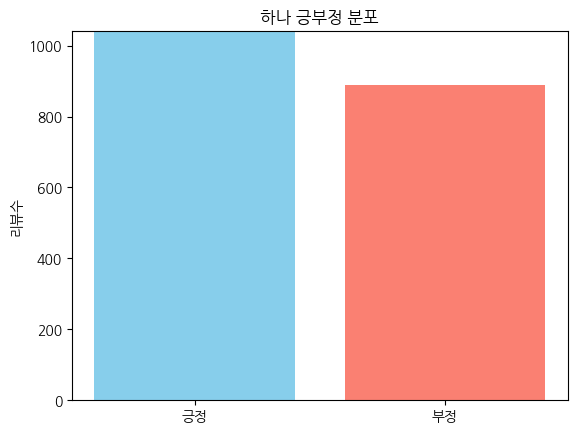

1042 890
신한 shinhan


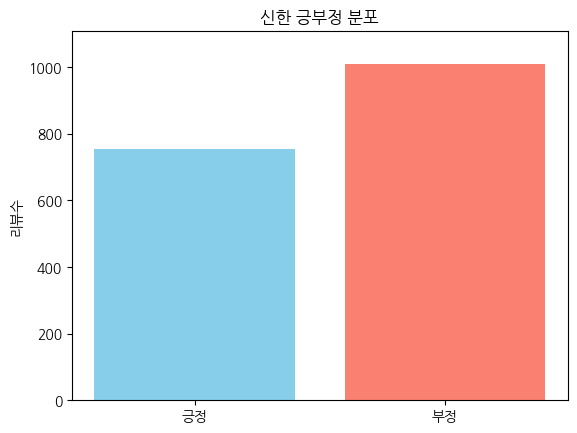

755 1009
국민 kb


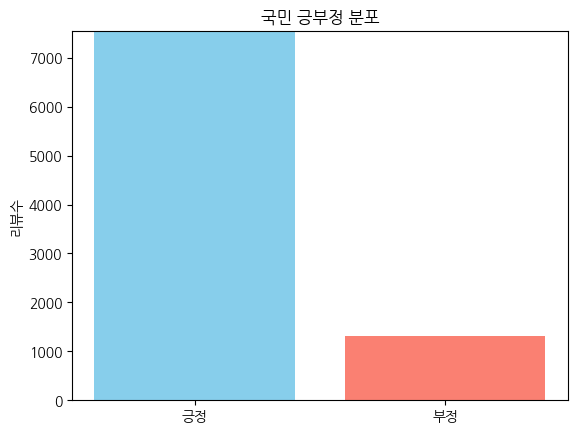

7553 1310
토스 toss


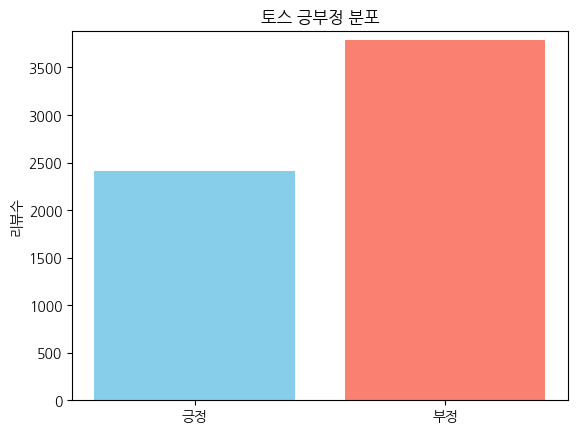

2415 3786
우리 woori


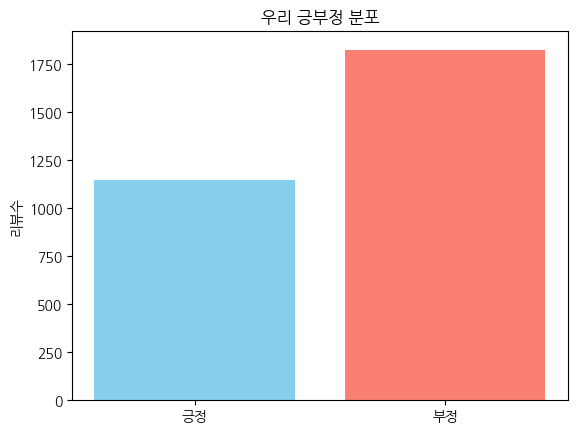

1146 1823
뱅크샐러드 b_salad


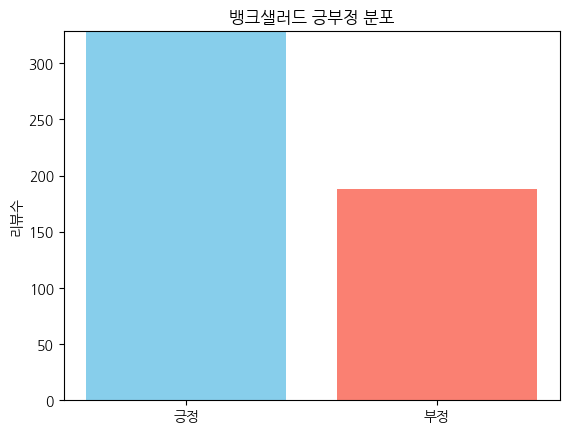

329 188


{'hana': {'pos':               리뷰일  평점                                              사용자리뷰  \
  0      2023-12-21   5            엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 저도 쓰고있음   
  27     2024-05-07   4  Not Found 실행이 안됩니다 하나은행 어플 누르면 Not Found 메세지 뜨...   
  58     2024-09-05   5            뱅킹 잘 이용하고 있어요 항상친절 하게 설명 해 주셔서 감사 수고하세요   
  59     2024-03-15   5                                             잘쓰고잇어용   
  66     2024-11-30   5                                              감사합니다   
  ...           ...  ..                                                ...   
  22120  2024-10-11   5                       입 출 현황을 확인할 수 있어 매우 편리하고 좋아요   
  22165  2023-10-11   5                                        최고입니다 감사합니다   
  22196  2024-12-30   5                                              감사합니다   
  22202  2023-07-03   5                                           간편하고 좋네요   
  22214  2023-06-14   5                                                좋아요   
  
                                              

In [32]:
pos_neg_dict = {}
for bank, bank_eng in bank_list_dict.items():
    print(bank, bank_eng)
    pos = train_df[(train_df['은행명'] == bank) & (train_df['긍정'] == 1)]
    neg = train_df[(train_df['은행명'] == bank) & (train_df['긍정'] == 0)]
    
    # bank_eng 기준으로 pos/neg 저장
    pos_neg_dict[bank_eng] = {
        "pos" : pos,
        "neg" : neg
    }
    
    # 시각화
    plt.bar(['긍정', '부정'], [pos.shape[0], neg.shape[0]], color=['skyblue', 'salmon'])
    plt.title(f"{bank} 긍부정 분포")
    plt.ylabel("리뷰수")
    plt.ylim(0, max(pos.shape[0], neg.shape[0] +100))
    plt.show()
    print(pos.shape[0], neg.shape[0])
pos_neg_dict

# 은행별 긍부정 리뷰 워드클라우드 만들기

In [33]:
# !pip install wordcloud

# 🌀 워드클라우드(WordCloud) 만들기 
한국어 리뷰 데이터 분석 + 시각화

---

## 1. 워드클라우드란?

- 텍스트 데이터에서 **단어의 등장 빈도수**를 기준으로  
  단어 크기·배치·색상을 다르게 표현하는 시각화 기법이다.
- 등장 빈도가 높을수록 크게, 낮을수록 작게 표시된다.
- 리뷰, 설문, 댓글, SNS 데이터의 **핵심 키워드 탐색**에 매우 효과적이다.

---

## 2. 라이브러리 설치

```bash
pip install wordcloud
```

# ⚠️ 한국어 워드클라우드(font_path 필수)  
한국어 워드클라우드를 만들 때는 반드시 **font_path** 옵션을 지정해야 한다.  
지정하지 않으면 한글이 깨지거나 네모(□)로 출력된다.

---

# 3. 작업 흐름 개요

1. **텍스트 데이터 준비**  
   - pandas Series → 리스트(list) → 하나의 긴 문자열로 합치기

2. **텍스트 정제(전처리)**  
   - 정규표현식으로 특수문자 제거  
   - 필요 시 소문자 변환, 공백 정리 등 추가 처리

3. **한국어 형태소 분석으로 명사 추출**  
   - MeCab, Okt, Komoran 등  
   - 워드클라우드는 명사 위주로 작성하는 것이 가장 효과적

4. **불용어(stopwords) 제거**  
   - ‘은행’, ‘앱’, ‘어플’ 같은 너무 일반적인 단어 제거  
   - 브랜드명(하나, 국민, 신한 등)도 필요 시 제거

5. **단어 빈도수 계산 (Counter)**  
   - Counter(filtered_words) 형태로 {단어: 등장 횟수} 사전(dictionary) 생성

6. **WordCloud 옵션 지정**  
   - font_path  
   - width / height  
   - background_color  
   - max_words, max_font_size 등  
   - 필요 시 colormap, mask 옵션 설정

7. **generate_from_frequencies()로 워드클라우드 생성**

8. **시각화 및 파일 저장**  
   - matplotlib으로 표시  
   - .png 파일로 저장 가능

---

# 4. 텍스트 데이터 준비 + 전처리

## 4.1 텍스트 합치기

리뷰가 Series 형태라면 다음과 같이 리스트로 변환 후 하나의 문자열로 합칠 수 있다.

```python
# 리뷰 Series → 리스트 → 하나의 문자열로 변환
text_data = df['사용자리뷰'].astype(str).tolist()
full_text = " ".join(text_data)
```
* .astype(str) : NaN/None 발생 시 안전하게 문자열 변환
* .tolist() : pandas Series → Python list
* " ".join(list) : 하나의 긴 문자열로 연결

## 4.2 텍스트 정제(전처리)

정규표현식을 사용해 한글/숫자/알파벳만 남기고 나머지를 제거한다.
```python
import re

def text_clean(x):
    pattern = r'[가-힣0-9a-zA-Z]+'
    matches = re.findall(pattern, str(x))
    return " ".join(matches)

# 전처리 적용
df['사용자리뷰'] = df['사용자리뷰'].astype(str).apply(text_clean)

```
* [가-힣0-9a-zA-Z]+ : 한글 전체 + 숫자 + 영어만 추출
* 리뷰 문장에서 이모지, 특수문자, 기호 등을 제거해 깔끔한 텍스트 확보

## 5. 형태소 분석 + 불용어 제거

한국어 텍스트는 공백 기반 토큰화가 어렵기 때문에 **MeCab 등 형태소 분석기로 명사만 추출**하는 방식이 가장 효과적이다.

### 5.1 MeCab 명사 추출

```python
from konlpy.tag import Mecab
mecab = Mecab()
nouns = mecab.nouns(full_text)
```

---

### 5.2 불용어(stopwords) 정의

```python
stopwords = set([
    '은행', '어플', '뱅킹', '앱', '서비스', '고객',
    '하나', '국민', '신한', '우리',
    'toss', '카드'
])
```

---

### 5.3 불용어 제거 + 한 글자 단어 제거

```python
filtered = [
    word for word in nouns
    if len(word) > 1 and word not in stopwords
]
```

---

## 6. 단어 빈도 계산

```python
from collections import Counter
word_freq = Counter(filtered)
```

---

## 7. WordCloud 옵션 상세 설명

```python
from wordcloud import WordCloud

wc = WordCloud(
    font_path="NanumGothic.ttf",
    background_color="white",
    width=800, height=400,
    max_words=200,
    max_font_size=120,
    min_font_size=4,
    colormap="tab10",
    prefer_horizontal=0.9,
    scale=2,
    stopwords=None,
    mask=None,
    contour_width=0,
    contour_color='black'
)
```

| 옵션 | 의미 |
|------|------|
| font_path | 한글 폰트 경로 |
| background_color | 배경색 |
| width/height | 이미지 크기 |
| max_words | 최대 단어 수 |
| max_font_size | 글자 최대 크기 |
| min_font_size | 글자 최소 크기 |
| colormap | 색상 팔레트 |
| prefer_horizontal | 가로 배치 비율 |
| scale | 고해상도 렌더링 배율 |
| mask | 특정 모양 마스크 |
| contour_width/color | 외곽선 효과 |

---

## 8. generate() vs generate_from_frequencies()

### generate(text)

```python
wc.generate(full_text)
```

---

### generate_from_frequencies(freq_dict)

```python
wc.generate_from_frequencies(word_freq)
```

> 한국어 분석에서는 **generate_from_frequencies()** 방식이 훨씬 정확하다.



In [34]:
from wordcloud import WordCloud

In [35]:
hana_pos = " ".join(pos_neg_dict['hana']['pos']['사용자리뷰'].tolist())

In [36]:
stopwords = set(['은행', '어플', '뱅킹', '앱', '하나', 'toss', '신한은행'])

In [37]:
"은행" not in stopwords

False

In [38]:
nouns = mecab.nouns(hana_pos)
filtered = [word for word in nouns if len(word) > 1 and word not in stopwords]

In [39]:
from collections import Counter

In [40]:
word_freq = Counter(filtered)
word_freq

Counter({'편리': 170,
         '사용': 134,
         '감사': 53,
         '가입': 40,
         '이용': 35,
         '만족': 33,
         '계좌': 31,
         '최고': 30,
         '거래': 27,
         '친절': 26,
         '설명': 21,
         '불편': 18,
         '이체': 17,
         '상품': 17,
         '처리': 16,
         '업데이트': 15,
         '번호': 14,
         '서비스': 14,
         '가능': 14,
         '인증': 14,
         '설치': 13,
         '적금': 13,
         '기능': 13,
         '통장': 12,
         '이벤트': 12,
         '금융': 12,
         '오류': 12,
         '확인': 11,
         '대출': 11,
         '해결': 11,
         '시간': 11,
         '정보': 10,
         '상태': 10,
         '추천': 10,
         '직관': 9,
         '개선': 9,
         '변경': 9,
         '이해': 9,
         '화면': 9,
         '정확': 9,
         '혜택': 9,
         '조아': 8,
         '문제': 8,
         '처음': 8,
         '입출금': 8,
         '카드': 8,
         '메뉴': 8,
         '때문': 8,
         '생각': 8,
         '방문': 8,
         '실행': 7,
         '이상': 7,
         '상담원': 7,
    

In [41]:
hana_pos

'엄빠 폰에 설치해드렸는데 두분 다 쓰기 편하다고 하시네요 저도 쓰고있음 Not Found 실행이 안됩니다 하나은행 어플 누르면 Not Found 메세지 뜨면서 튕기네요 재부팅도 해보고 어플 삭제 후 재설치 해도 마찬가지네요 참고로 3년간 아무이상 없이 잘 사용했고 오늘 갑자기 이럽니다 뱅킹 잘 이용하고 있어요 항상친절 하게 설명 해 주셔서 감사 수고하세요 잘쓰고잇어용 감사합니다 등 h 2 5s0 아직까지 잘 사용하고 있습니다 좋음 매우 잘 쓰고 있습니다 그런데 앱이 실행이 안되네요 월급통장 자유적금 안내가 바로나와서 너무 편하고 좋네요 직관적으로 알아보기 쉬워요 쓰기 편함 굿입니다 원하는대로 척척 다됩니다 일상생활에 늘 사용중입니다 알람이 안떠서 직접 가서 알람 뜨도록 설정 을 했는데 돈만 가져가고 알람 안뜨네요 은행에서도 가서 얘기를 했더니 알람 뜨게 설정했다고 말만 하고 조취를 안해주네요 이제는 앱 들어 갈라고 할때마다 튕귀고 폰 껐다켰다 해봐도 안 들어가지네요 하나에 이체 보내야 되는데 못하고 있고 하나 업데이트 해라고 뜨는데 막상 스토어에들어가서 업데이트 할라니깐 업데이트가 안뜨고 뭐 어떻게 해라는지 모르겠네요 굿 Gooooo good 굿 조아요 우리는 하나다 한반도는 하나의 민족임을 알려주는 하나은행입니다 운전면허증을 촬영했으나 2번이나 사본 대신 원본을 촬영하라는 메시지가 떠서 결국은 3번을 촬영하고 나서야 확인됨 인식 기능에 문제가 있는 것으로 사료되오니 개선하여 주십시오 감사합니다 앱에서 혼자 다 할수있게 설명 잘되어있어요 쉽게 설명돼 있어서 좋으네요 간단하게 대출이 되네요 자산관리 한눈에 보이게 정리해 줘서 정말 편합니다 언제 얼마나 지출했는지 그래프로 보여주니 한눈에 보이고 좋아요 사용이 편리해요 좋아요 잘보이고요 티켓 사려고 설치했는데 계좌 없어도 되네요 좋아요 사용하기로 편해서 좋아요 좋습니다 대출 알아봤는데 잘 해결했습니다 고맙습니다 다른 은행 앱이랑 다르게 빠르고 모바일로 처리할수 있는 일도 많은듯 꽤 편리하네요 매우 만족합니다 잘쓰

In [42]:
# ubuntu 터미널에서 나눔폰트 설치
# sudo apt update
# sudo apt install fonts-nanum -y

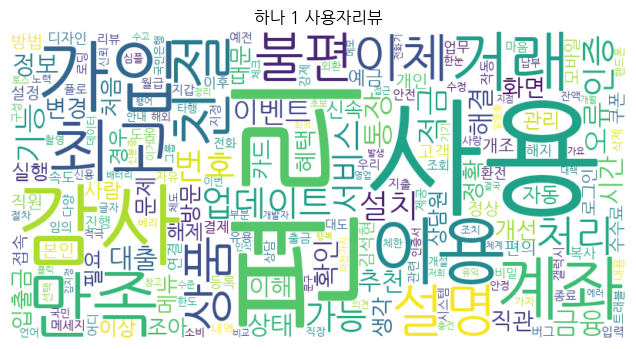

In [43]:
wc = WordCloud(
    font_path="NanumGothic.ttf",
    background_color='white',
    width = 800,
    height=400
    ).generate_from_frequencies(word_freq)
plt.figure(figsize=(8,4))
plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.title(f"{pos_neg_dict['hana']['pos']['은행명'].unique()[0]} {pos_neg_dict['hana']['pos']['긍정'].unique()[0]} 사용자리뷰")
plt.show()
          

In [44]:
hana_neg = " ".join(pos_neg_dict['hana']['neg']['사용자리뷰'].tolist())

In [45]:
nouns = mecab.nouns(hana_neg)
filtered = [word for word in nouns if len(word) > 1 and word not in stopwords]

In [46]:
from collections import Counter

In [47]:
word_freq = Counter(filtered)
word_freq

Counter({'인증': 207,
         '로그인': 147,
         '계좌': 137,
         '오류': 113,
         '등록': 110,
         '실행': 109,
         '사용': 98,
         '화면': 88,
         '번호': 85,
         '업데이트': 80,
         '이체': 77,
         '접속': 73,
         '설정': 70,
         '설치': 70,
         '삭제': 61,
         '불편': 54,
         '로딩': 53,
         '이용': 49,
         '입력': 48,
         '거래': 47,
         '확인': 47,
         '시간': 45,
         '가입': 44,
         '건지': 43,
         '처음': 42,
         '비밀': 41,
         '에러': 41,
         '짜증': 41,
         '최악': 40,
         '문제': 40,
         '해결': 40,
         '쓰레기': 39,
         '무한': 38,
         '광고': 38,
         '인식': 37,
         '신분증': 36,
         '금융': 35,
         '통장': 33,
         '기능': 33,
         '초기': 33,
         '가능': 32,
         '때문': 32,
         '카드': 32,
         '필요': 31,
         '종료': 30,
         '정보': 29,
         '반복': 28,
         '원격': 27,
         '자동': 27,
         '이후': 26,
         '시작': 26,
         '발급': 26,
 

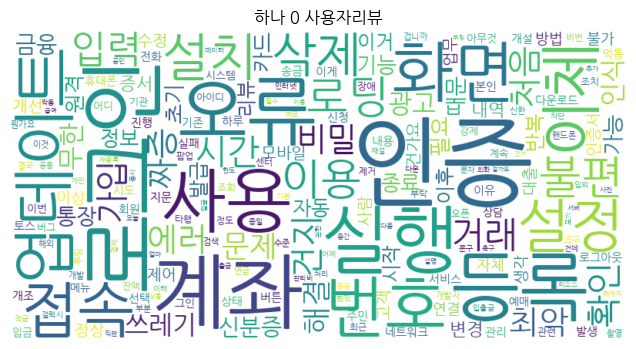

In [48]:
wc = WordCloud(
    font_path="NanumGothic.ttf",
    background_color='white',
    width = 800,
    height=400
    ).generate_from_frequencies(word_freq)
plt.figure(figsize=(8,4))
plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.title(f"{pos_neg_dict['hana']['neg']['은행명'].unique()[0]} {pos_neg_dict['hana']['neg']['긍정'].unique()[0]} 사용자리뷰")
plt.show()

# 반복문으로 은행별 만족/불만족 워드클라우드 그리기

In [49]:
stopwords

{'toss', '뱅킹', '신한은행', '앱', '어플', '은행', '하나'}

In [50]:
import os

============================== hana pos ==============================


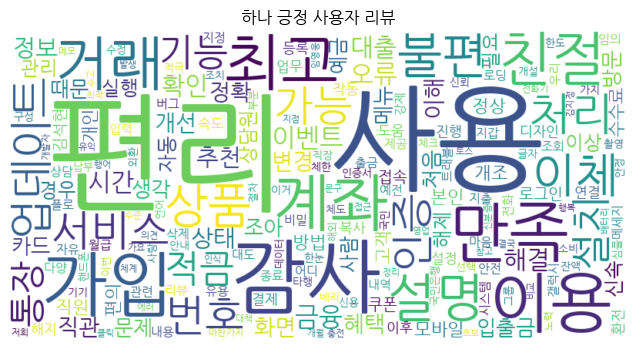

============================== hana neg ==============================


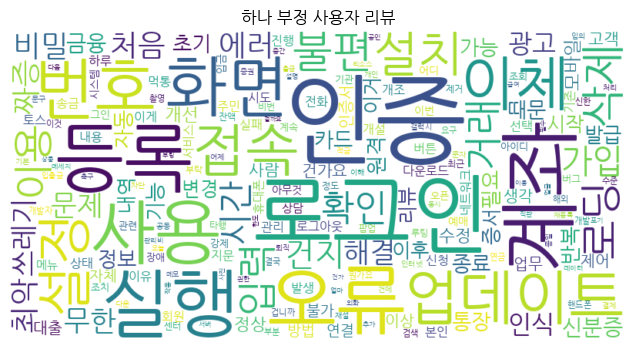

============================== shinhan pos ==============================


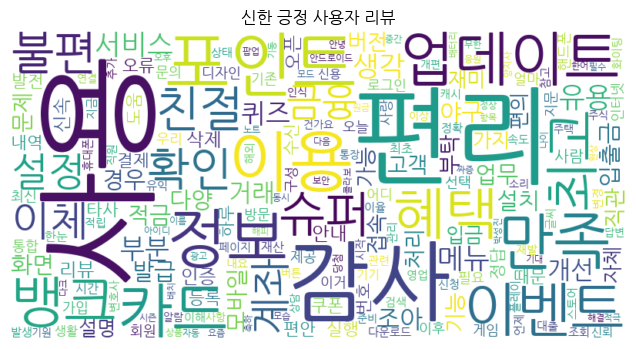

============================== shinhan neg ==============================


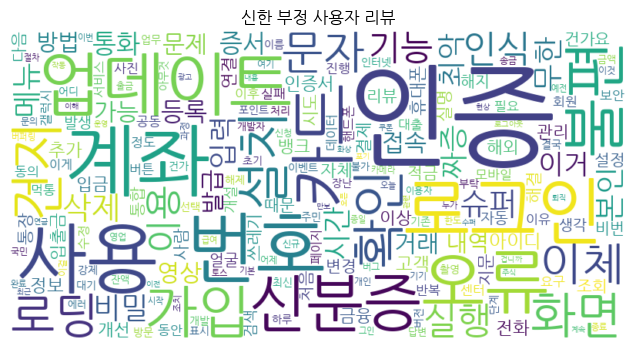

============================== kb pos ==============================


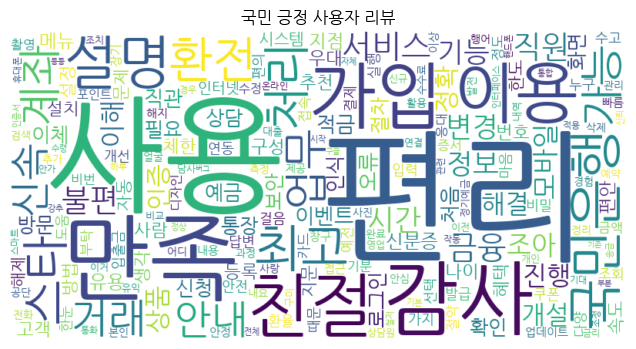

============================== kb neg ==============================


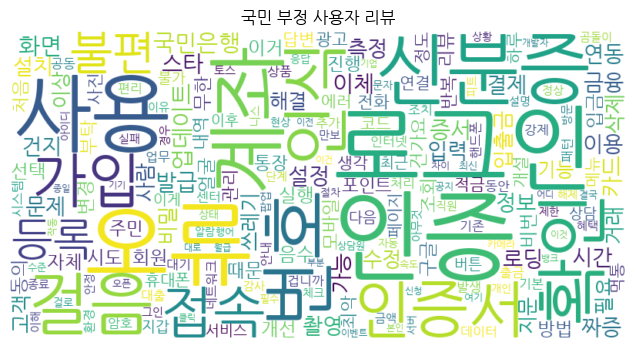

============================== toss pos ==============================


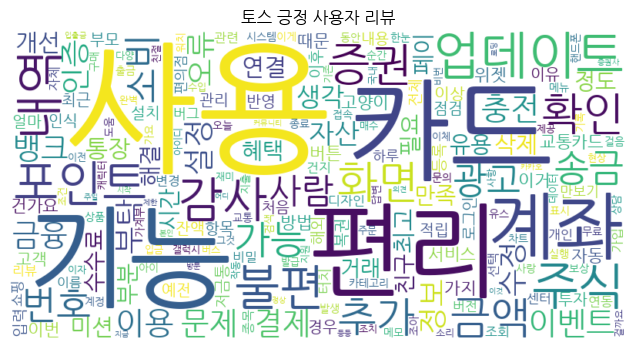

============================== toss neg ==============================


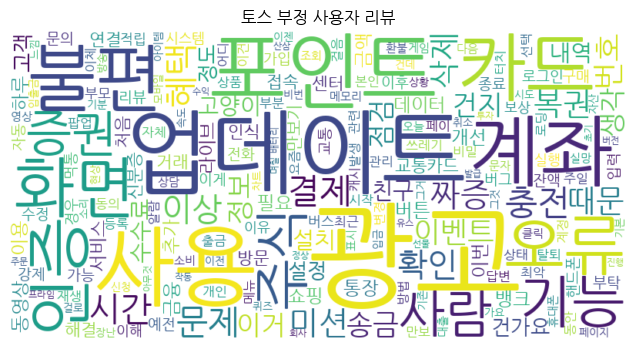

============================== woori pos ==============================


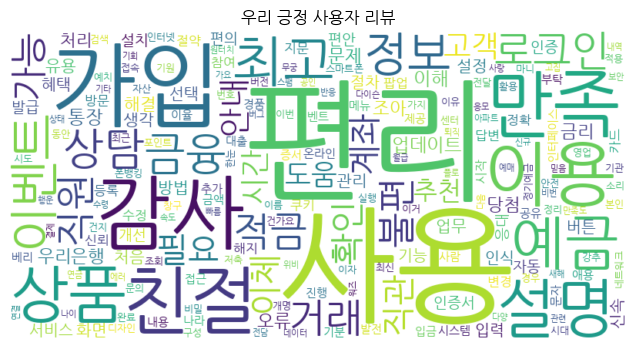

============================== woori neg ==============================


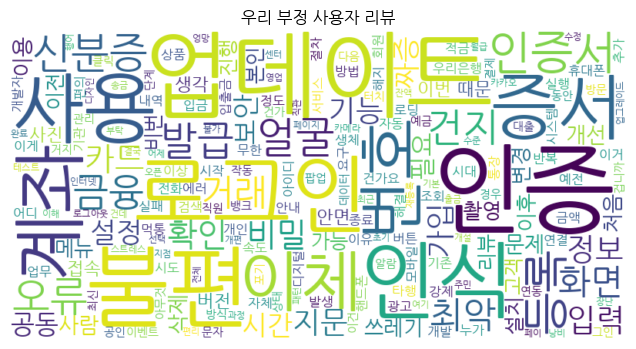

============================== b_salad pos ==============================


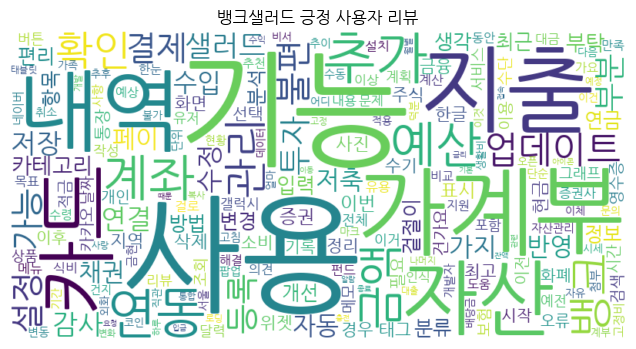

============================== b_salad neg ==============================


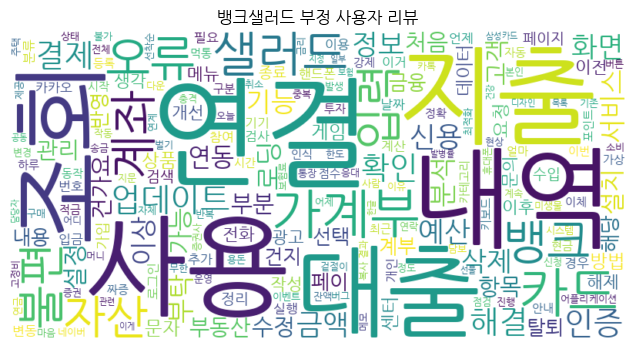

In [51]:
for bank_eng, pos_neg in pos_neg_dict.items():
    for label, df in pos_neg.items():
        print("=" * 30, bank_eng, label, "=" * 30)
        full_text = " ".join(df['사용자리뷰'].tolist())
#         print(full_text[:100])
        
        # 은행 이름을 불용어에 추가
        bank_name = df['은행명'].iloc[0]
        stopwords.add(bank_name)
        
        # 명사 추출
        nouns = mecab.nouns(full_text)
        filtered = [word for word in nouns if len(word) > 1 and word not in stopwords]
        
        # 단어의 빈도 계산
        word_freq = Counter(filtered)
#         print(word_freq)
        
        wc = WordCloud(
                font_path="NanumGothic.ttf",
                background_color='white',
                width = 800,
                height=400
                ).generate_from_frequencies(word_freq)
        
        # 긍/부정 레이블 텍스트 만들기
        sentiment_txt = "긍정" if label == 'pos' else "부정"
        
        plt.figure(figsize=(8,4))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis('off')
        plt.title(f"{bank_name} {sentiment_txt} 사용자 리뷰")
        
        if not os.path.exists("img"):
            os.mkdir("img")
        save_name = f"./img/{bank_name} {sentiment_txt} 사용자 리뷰.png"
        plt.savefig(save_name, dpi=300, bbox_inches='tight')
        plt.show()

# 📘 LDA 기반 최적 토픽 추출 (토픽 모델링)
### ― 한국어 리뷰 + Mecab 형태소 분석 + gensim Coherence 기반 토픽 개수 최적화 ―
* LDA는 문서 집합에서 주제를 추출하는 토픽모델링 기법
* 각 문서(리뷰 1개)는 여러 주제들로 구성되어 있고, 각 주제는 특정 단어들의 분포로 표현된다는 베이지안 확률에 기반


## 1. 토픽 모델링(Topic Modeling)이란?

토픽 모델링은 **문서 집합 속에 숨어 있는 주제(Topic)들을 자동으로 발견하는 비지도 학습 기법**이다.   
텍스트 데이터(예: 상품 리뷰, 설문 답변, 고객 불만 글 등)에 라벨이 없어도, 텍스트 내부 패턴을 분석해 문서들이 어떤 주제들을 중심으로 구성되어 있는지 스스로 찾아낸다.

### ✔️ 토픽 모델링의 핵심 특징
- 지도학습이 아닌 **비지도 학습(Unsupervised)**  
- 단어들의 **동시 등장 패턴(co-occurrence)** 을 기반으로 주제를 추론  
- 하나의 문서는 **복수의 토픽으로 구성될 수 있음**  
- 각 토픽은 특정 단어가 높은 확률로 등장하는 **단어 확률 분포**로 표현됨



## 2. LDA(Latent Dirichlet Allocation)의 개념

LDA는 토픽 모델링을 위한 가장 대표적이고 고전적인 확률 기반 모델이다.  
문서가 “토픽들의 혼합물”이고, 각 토픽은 “단어들의 혼합물”이라는 가정 위에서 작동한다.

### ✔️ LDA의 기본 가정
1. **각 문서(doc)는 여러 토픽(topic)들의 확률적 혼합물이다.**  
   - 예: 30% 품질 관련 토픽, 50% 가격 관련 토픽, 20% 배송 관련 토픽

2. **각 토픽(topic)은 특정 단어들의 확률 분포이다.**  
   - 예: “배송” 토픽 → {배송, 빠름, 느림, 기사, 택배, …}

3. **문서 생성 과정(확률적 모델링)**
   - 문서마다 “토픽 분포”를 하나 샘플링  
   - 해당 토픽 분포에서 특정 토픽을 선택  
   - 토픽이 가진 “단어 분포”에서 단어 하나를 선택  
   - 이 과정을 반복해 문서 전체의 단어들을 생성했다고 가정

LDA는 이 “문서 생성 과정”을 역으로 추론하여:
- 어떤 토픽들이 문서 집합 속에 존재하는지  
- 각 토픽은 어떤 단어들로 구성되는지  
- 각 문서는 어떤 토픽들로 구성되어 있는지  

를 계산해준다.



## 3. 한국어 리뷰에서 LDA를 적용할 때의 특징

한국어는 영어와 달리 **형태소 기반 언어**이다.  
따라서 LDA를 적용하기 전에 “형태소 분석기”를 활용한 전처리가 필수적이다.

### ✔️ 한국어 처리의 핵심 단계
1. **형태소 분석(Mecab 등)**  
   - 문장을 “단어(형태소)” 단위로 쪼개고 품사 태깅  
   - 명사(NNG, NNP), 형용사(VA), 동사 어간 등 주요 정보만 추출

2. **불용어(stopwords) 제거**  
   - 의미 없는 단어(하다, 되다, 있다, 너무, 그리고…) 제거  
   - 데이터 도메인(쇼핑, 은행, 리뷰 등)에 맞춰 커스터마이징

3. **단어 리스트 생성**  
   - LDA는 단어의 등장 빈도를 기반으로 하므로,  
     “의미 있는 단어만 남긴 리스트”가 모델 성능의 핵심

4. **BoW(Bag-of-Words) 기반 표현 생성**  
   - 각 문서에서 단어가 몇 번 등장했는지 정수 형태로 표현  
   - LDA는 BoW 또는 TF-IDF 형태를 입력으로 사용



## 4. gensim의 Dictionary와 Corpus

### ✔️ Dictionary
- 전체 문서의 단어들을 수집하여  
  **“단어 → 고유 id”** 매핑을 만든 구조  
- LDA 입력의 필수 요소

### ✔️ Corpus
- 각 문서를  
  **[(단어 id, 단어 등장 횟수), …]**  
  형태로 표현한 리스트
- LDA 모델은 이 Corpus를 기반으로 학습한다.

이 두 구조는 LDA의 입력 역할을 하며, 모델이 문서-단어 관계를 수학적으로 계산할 수 있도록 해준다.



## 5. 토픽 수(k)는 왜 최적화를 해야 할까?

LDA는 **토픽 개수를 자동으로 결정하지 못하는 모델**이다.  
사용자가 직접 **몇 개의 토픽을 만들 것인지(k)** 를 지정해야 한다.

### ✔️ 토픽 수를 잘못 선택하면?
- 너무 적으면: 각 주제가 과도하게 뭉뚱그려짐  
- 너무 많으면: 의미 없는 쪼개진 토픽이 다수 생성됨  
- 적절한 k 선택이 필수

### ✔️ 토픽 개수 평가 지표: Coherence Score
Coherence는 **토픽 내 단어들이 서로 얼마나 의미적으로 관련성이 높은지** 판단하는 지표다.

예를 들어:
- 토픽 단어가 {배송, 택배, 기사, 빠름, 도착} → 일관성 높음  
- 토픽 단어가 {배송, 맛있다, 친절, 가격, 프로그램} → 일관성 낮음  

Coherence 점수는 “사람이 보기에 자연스러운 토픽”일수록 높은 값을 갖는다.  
따라서 **여러 개의 k를 실험하고 Coherence가 가장 높은 값을 선택하는 방식**이 일반적이다.



## 6. 최적 토픽 개수 산출 과정 (개념)

최적 k를 찾는 과정은 다음과 같다.

---

### **① 사전(Dictionary)과 코퍼스(Corpus) 준비**  
- 전처리된 토큰 리스트 → Dictionary 생성  
- 각 문서 → Bag-of-Words 형태로 Corpus 생성  

---

### **② 다양한 토픽 수(k)에 대해 LDA 모델 반복 학습**  
- k = 2, 3, 4, … 10 (혹은 2~20 등 원하는 범위)  
- 각 k에 대해 LDA 모델 1개씩 학습  
- 동일한 데이터, 동일한 전처리 조건에서 실험

---

### **③ 각 LDA 모델의 Coherence Score 계산**

Coherence는 gensim의 CoherenceModel에서 제공하며,  
다음 요소를 기반으로 계산된다:

- 각 토픽의 상위 단어들  
- 단어들 간의 동시 등장 통계  
- 단어 벡터 공간에서의 의미적 유사성  
- 사람이 이해하기 쉬운 토픽 구성인지 평가하는 개념적 메트릭

---

### **④ 토픽 수별 Coherence 점수를 비교하여 최적 k 선택**

예시(개념):

| 토픽 수(k) | Coherence |
|------------|-----------|
| 3 | 0.43 |
| 4 | 0.56 |
| 5 | **0.61 (최고)** |
| 6 | 0.59 |
| 7 | 0.57 |

→ 최적 토픽 수는 **k=5**  

이런 방식으로 최적 토픽 개수를 자동적으로 결정한다.



## 7. 최종 LDA 모델 해석

최적 k가 결정되면, 해당 k로 LDA를 재학습하고 다음을 분석한다.

---

### ✔️ (1) 토픽 정의하기  
각 토픽의 **상위 단어**(Top-N words)를 기반으로 토픽의 의미를 해석한다.

예시(개념):

- 토픽 0 → 배송, 빠름, 기사, 도착, 택배  
- 토픽 1 → 가격, 할인, 이벤트, 세일  
- 토픽 2 → 품질, 제품, 내구성, 고장, 불량  

---

### ✔️ (2) 각 문서의 토픽 분포  
문서마다 “토픽 혼합 비율”이 계산된다.

예시:

| 문서 | 토픽0 | 토픽1 | 토픽2 | 대표 토픽 |
|------|-------|-------|-------|------------|
| A | 0.65 | 0.20 | 0.15 | 토픽0 |
| B | 0.10 | 0.70 | 0.20 | 토픽1 |
| C | 0.05 | 0.15 | 0.80 | 토픽2 |

- 비율이 가장 높은 토픽이 “해당 문서의 대표 토픽”  
- 문서별 대표 토픽을 활용하면 **리뷰 분류**나 **이슈 클러스터링**이 가능

---

### ✔️ (3) 비즈니스/실무 활용

- 리뷰 토픽별 분류 → **고객 VOC 분석 자동화**  
- 기간별 토픽 변화 → **이슈 변화 추적(Dashboard)**  
- 긍정/부정 리뷰로 나누어 LDA → **What customers like / dislike** 자동 추출  
- 마케팅/기능 개선 → **주요 고객 불만 토픽 파악**



## 8. LDA의 주요 하이퍼파라미터 개념적 이해

### 🔷 num_topics  
- 생성할 토픽 개수  
- Coherence 기반으로 자동 선택 가능  

### 🔷 passes  
- 전체 코퍼스를 몇 번 반복해서 학습할지  
- 클수록 수렴이 잘 되나 시간 증가  

### 🔷 chunksize  
- 한 번에 처리하는 문서 수  
- 메모리/속도 조절 목적  

### 🔷 alpha (문서-토픽 분포의 희소성)  
- 작으면: 한 문서에 소수의 토픽만 등장  
- 크면: 문서에 다양한 토픽이 골고루 등장  

### 🔷 eta (토픽-단어 분포의 희소성)  
- 작으면: 토픽이 소수 단어에 집중  
- 크면: 토픽이 다양한 단어를 고르게 포함  
- ‘auto’ 사용 시 gensim이 적절하게 추정  



## 9. LDA 기반 최적 토픽 모델링의 전체 프로세스 요약

1. **데이터 수집**
   - 리뷰, 댓글, 코멘트 등

2. **텍스트 전처리**
   - 불필요한 기호, 숫자, 이모지 제거  
   - 한글 정규화

3. **형태소 분석 (Mecab)**
   - 명사/형용사 등 의미 있는 단어만 추출  
   - 불용어 제거

4. **Dictionary 생성**
   - 전체 단어 → 고유 ID 매핑

5. **Corpus 생성**
   - 문서 → BoW 구조

6. **토픽 수(k)를 2~N까지 범위로 설정하여 LDA 반복 학습**

7. **각 k에 대해 Coherence Score 계산**

8. **Coherence가 가장 높은 k 선택 → 최적 토픽 수 결정**

9. **최적 k로 LDA 재학습**

10. **토픽 상위 단어 확인 후 토픽 의미 해석**

11. **문서별 대표 토픽 추출 및 활용**



## 10. 정리

LDA 기반 토픽 모델링은  
- 대규모 텍스트 데이터를 **자동으로 요약**하고  
- 리뷰/코멘트 등을 **토픽 단위로 구조화**하여  
- **비즈니스 인사이트 도출**을 가능하게 하는 강력한 분석 기법이다.

특히 한국어 데이터에서는  
- Mecab 기반 형태소 분석  
- 불용어 제거  
- 코퍼스 구조화  
이 필수적이며,  
최적 토픽 개수는 **Coherence Score**를 활용해 객관적으로 선택할 수 있다.


# 최적 토픽 개수 구하고 리뷰에서 토픽 추출하기
* gensim 모듈 사용
* mecab을 이용해서 형태소 분리 후 벡터화
* coherence 점수를 계산해서 최적 토픽 개수 산출

In [52]:
# !pip install gensim

In [53]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim import corpora
from gensim.models.coherencemodel import CoherenceModel
from konlpy.tag import Mecab
mecab = Mecab()

In [54]:
def mecab_tokenizer(text):
    return [w for w in mecab.nouns(str(text)) if len(w) > 1]

# 최적 토픽 수 탐색

In [55]:
def find_optimal_topics(texts, start=2, end=20, min_df=5, max_df=0.9, topn=10, random_state=42):
    # list로 변경된 series를 토큰화하고 길이 2이상인 것만 남김
    pairs = [(t, mecab_tokenizer(t)) for t in texts]
    pairs = [(t, tok) for (t, tok) in pairs if len(tok) >= 2]
#     print(pairs)
    filtered_texts = [t for (t, tok) in pairs]
    tokenized_texts = [tok for (t, tok) in pairs]
    
#     print(tokenized_texts)
    if len(tokenized_texts) < 5:
        return start, filtered_texts, tokenized_texts
    
    # 토픽이 너무 많은 경우 숫자 제한
    max_k = min(end, max(start, len(tokenized_texts) // 2))
    if max_k < start:
        return start, filtered_texts, tokenized_texts
    
    # coherence 계산용 dictionary 만들기
    dictionary = corpora.Dictionary(tokenized_texts)

#     print("단어 개수", len(dictionary))
#     print("샘플 단어", list(dictionary.token2id.keys())[:100])
    
    # 문자를 벡터화
    vectorizer = CountVectorizer(
        tokenizer=mecab_tokenizer,
        preprocessor=None,
        token_pattern=None,
        lowercase=False,
        min_df=min_df,
        max_df=max_df)
    
    try:
        doc_term_matrix = vectorizer.fit_transform(filtered_texts)
    except Exception as e:
        print(e, "\n벡터화 오류, 기본 토픽수 반환")
        return start, filtered_texts, tokenized_texts
    
    if doc_term_matrix.shape[1] == 0:
        print("min_df, max_df로 단어 전부 제거, 기본 토픽수 반환")
        return start, filtered_texts, tokenized_texts
    
    feature_names = vectorizer.get_feature_names_out()
    
    best_score = -1
    best_n = start
    
    for n_topics in range(start, max_k + 1):
        lda_model = LatentDirichletAllocation(
                n_components=n_topics,
                random_state=random_state,
                learning_method='batch')
        lda_model.fit(doc_term_matrix)
        
        topics = [
            [feature_names[i] for i in topic.argsort()[:-topn-1:-1]]
            for topic in lda_model.components_
        ]
        
        cm = CoherenceModel(
            topics=topics,
            texts=tokenized_texts,
            dictionary=dictionary,
            coherence="c_v"
            )
        score = cm.get_coherence()
        
        print(f"토픽수: {n_topics}, Coherence Score: {score:.4f}")
        
        if score > best_score:
            best_score = score
            best_n = n_topics
    
    print(f"최적 토픽수: {best_n} (score: {best_score:.4f})")
    return best_n, filtered_texts, tokenized_texts


# 토픽모델링

In [56]:
print("--- 토픽 모델링 시작 ---")
VEC_MIN_DF = 10
VEC_MAX_DF = 0.9

topn_words_print = 10
topn_coherence = 10

start_k = 2
end_k = 20

topic_words_map = {}

for bank_eng, pn in pos_neg_dict.items():
    for senti in pn:
        series = pn[senti]['사용자리뷰']
        texts = series.tolist()
        
        # 최적 토픽수 + 필터된 문서 + 토큰화된 리스트 함께 받기
        best_k, filtered_texts, tokenized_texts = find_optimal_topics(
            texts=texts,
            start=start_k,
            end=end_k,
            min_df=VEC_MIN_DF,
            max_df=VEC_MAX_DF,
            topn=topn_coherence,
            random_state=42
            )
        
        # 
        if len(tokenized_texts) < 20:
            print(f"{bank_eng} ({senti}) 유효 토큰 문서 부족 ({len(tokenized_texts)}개) - 스킵")
            continue
        
        # 카운터벡터라이저로 문자 => 숫자          
        vectorizer = CountVectorizer(
            tokenizer=mecab_tokenizer,
            preprocessor=None,
            token_pattern=None,
            lowercase=False,
            min_df=VEC_MIN_DF,
            max_df=VEC_MAX_DF)
                  
        try:
            review_vec = vectorizer.fit_transform(filtered_texts)
        except Exception as e:
            print(e, f"\n{bank_eng} ({senti}) 벡터화 오류, 기본 토픽수 반환")
            continue

        if review_vec.shape[1] == 0:
            print(f"{senti} min_df 조건 만족 단어 없음 - 스킵")
            continue
        
        #최적 k로 lda 재학습
        lda = LatentDirichletAllocation(
                n_components=best_k,
                random_state=42,
                learning_method='batch')
        lda.fit(review_vec)
                  
        words = vectorizer.get_feature_names_out()
                  
        # 토픽 단어 출력 + 저장
        all_topic_words = set()
        
        print(f"\n[{bank_eng}] {senti} 토픽 {best_k}개 - 상위 단어")
        print("=" * 60)
        for i, topic in enumerate(lda.components_):
            top_idx = topic.argsort()[-topn_words_print:][::-1]
            top_words = [words[idx] for idx in top_idx]
            print(f"토픽 #{i}: {top_words}\n")
            all_topic_words.update(top_words)
            
        topic_words_map[(bank_eng, senti)] = all_topic_words
    print("--- 토픽 모델링 종료 ---")

--- 토픽 모델링 시작 ---
토픽수: 2, Coherence Score: 0.2764
토픽수: 3, Coherence Score: 0.2952
토픽수: 4, Coherence Score: 0.2754
토픽수: 5, Coherence Score: 0.3078
토픽수: 6, Coherence Score: 0.3024
토픽수: 7, Coherence Score: 0.3063
토픽수: 8, Coherence Score: 0.2703
토픽수: 9, Coherence Score: 0.2987
토픽수: 10, Coherence Score: 0.3050
토픽수: 11, Coherence Score: 0.2728
토픽수: 12, Coherence Score: 0.2839
토픽수: 13, Coherence Score: 0.2976
토픽수: 14, Coherence Score: 0.2919
토픽수: 15, Coherence Score: 0.3034
토픽수: 16, Coherence Score: 0.2927
토픽수: 17, Coherence Score: 0.2995
토픽수: 18, Coherence Score: 0.2874
토픽수: 19, Coherence Score: 0.3046
토픽수: 20, Coherence Score: 0.2774
최적 토픽수: 5 (score: 0.3078)

[hana] pos 토픽 5개 - 상위 단어
토픽 #0: ['계좌', '이체', '번호', '적금', '통장', '확인', '가능', '이용', '설치', '업데이트']

토픽 #1: ['가입', '설명', '상품', '만족', '확인', '서비스', '처리', '감사', '적금', '기능']

토픽 #2: ['은행', '하나', '감사', '이용', '친절', '처리', '설치', '업데이트', '설명', '편리']

토픽 #3: ['거래', '은행', '불편', '금융', '서비스', '가능', '업데이트', '하나', '이용', '이체']

토픽 #4: ['사용', '편리', '최고', '

토픽수: 3, Coherence Score: 0.4084
토픽수: 4, Coherence Score: 0.3666
토픽수: 5, Coherence Score: 0.3910
토픽수: 6, Coherence Score: 0.4081
토픽수: 7, Coherence Score: 0.4332
토픽수: 8, Coherence Score: 0.4167
토픽수: 9, Coherence Score: 0.4735
토픽수: 10, Coherence Score: 0.4498
토픽수: 11, Coherence Score: 0.4645
토픽수: 12, Coherence Score: 0.4911
토픽수: 13, Coherence Score: 0.4513
토픽수: 14, Coherence Score: 0.4753
토픽수: 15, Coherence Score: 0.4494
토픽수: 16, Coherence Score: 0.4620
토픽수: 17, Coherence Score: 0.4778
토픽수: 18, Coherence Score: 0.4852
토픽수: 19, Coherence Score: 0.4694
토픽수: 20, Coherence Score: 0.4397
최적 토픽수: 12 (score: 0.4911)

[toss] neg 토픽 12개 - 상위 단어
토픽 #0: ['계좌', '화면', '내역', '불편', '송금', '확인', '토스', '사용', '잔액', '업데이트']

토픽 #1: ['카드', '토스', '등록', '입력', '가능', '신청', '통장', '미만', '번호', '정보']

토픽 #2: ['미션', '방문', '고객', '토스', '센터', '주일', '터치', '대출', '정보', '확인']

토픽 #3: ['광고', '동영상', '데이터', '혜택', '강제', '재생', '영상', '금융', '기능', '자동']

토픽 #4: ['이벤트', '토스', '구매', '이거', '탈퇴', '리뷰', '핸드폰', '건데', '문의', '캐릭터']

토픽 #5: 

# LDA 기반 최적 토픽 추출 Word2vec 기반 t-SNE 시각화

## Word2Vec이란?

* **정의:** 단어를 **고정된 길이의 숫자 벡터(임베딩)**로 변환하는 기술이다.
* **핵심 원리 (분포 가설):** "비슷한 맥락(주변 단어)에서 등장하는 단어는 비슷한 의미를 가진다"고 가정한다.
* **작동:** AI가 문맥을 학습하여, 의미가 비슷한 단어들을 벡터 공간에서 **가까운 위치**에 배치한다.
* **학습 방식:**
    * **CBOW:** 주변 단어들로 **가운데 단어**를 예측한다. (빠름)
    * **Skip-gram:** 가운데 단어로 **주변 단어**들을 예측한다. (희귀 단어 학습에 유리)
* **벡터 특징:**
    * 단어 간 **유사도 계산**(코사인 유사도 등)이 가능하다.
    * 의미론적 **연산**이 가능하다. (예: `벡터("왕") - 벡터("남자") + 벡터("여자") ≈ 벡터("여왕")`)

---

### 💡 Word2Vec을 사용하는 이유 (LDA와 결합 시)

LDA가 **단어 빈도**를 기반으로 주제를 찾는다면, Word2Vec은 **단어 의미(문맥)**를 기반으로 한다.

이 두 가지를 결합하면, **LDA로 추출한 주제(토픽) 단어들이 실제로 서로 얼마나 의미적으로 가까운지**를 Word2Vec을 통해 분석하고 시각화할 수 있다.

---

## TSNE (t-SNE)란?

* **정의:** **고차원**의 복잡한 데이터(예: Word2Vec의 100차원 벡터)를 사람이 눈으로 볼 수 있는 **저차원(주로 2D)**으로 압축해 보여주는 **시각화 기술**이다.
* **핵심 원리:** 원래의 고차원 공간에서 **가까웠던 데이터(단어)들**은, 차원을 줄인 2D 공간에서도 **계속 가까이 모여 있도록** 배치한다.
* **주요 용도:** Word2Vec으로 만들어진 수백 차원의 단어 벡터들을 2D 평면에 점으로 찍어, **단어들이 어떻게 그룹(군집)을 이루는지** 눈으로 쉽게 확인하게 해준다.

---

## Gensim corpora.Dictionary

* **정의:** 텍스트(단어)를 **정수 ID**로, 또는 정수 ID를 다시 단어로 변환하는 **"단어 ↔ 정수 ID" 매핑 사전**이다.
    * 예: `{"배송": 0, "가격": 1, "품질": 2}`
* **주요 용도:**
    1.  AI 모델(LDA 등)이 텍스트를 처리할 수 있도록 숫자 형식(Bag of Words)으로 변환할 때 사용된다.
    2.  `CoherenceModel`(주제 일관성 점수)을 계산할 때 이 매핑 정보가 필요하다.

In [57]:
# !pip install tensorflow

# (LDA + Word2Vec + 2D t-SNE만 포함)

In [58]:
# tokenized = [mecab_tokenizer(t) for t in texts if len(toks) >= 2]
def tokenize_docs(texts):
    tokenized = []
    for t in texts:
        toks = mecab_tokenizer(str(t))
        if len(toks) >= 2:
            tokenized.append(toks)
    return tokenized

# word2vec 학습

In [59]:
from gensim.models import Word2Vec

In [60]:
w2v_model = None

all_reviews = train_df['사용자리뷰'].tolist()
all_tokenized = tokenize_docs(all_reviews)

if len(all_tokenized) >= 5:
    w2v_model = Word2Vec(
        sentences=all_tokenized,
        vector_size=100,
        window=5,
        min_count=2,
        workers=-1,
        sg=1,
        seed=42
        )
    print(f"Word2vec 학습완료 | 전체 리뷰 {len(all_reviews)} | 유효 토큰 문서: {len(all_tokenized)}")
else:
    print("word2vec 학습용 유효 토큰 문서가 너무 적어 학습 건너뜀")
    

Word2vec 학습완료 | 전체 리뷰 22246 | 유효 토큰 문서: 13730


In [61]:
topic_words_map

{('hana', 'pos'): {'가능',
  '가입',
  '감사',
  '거래',
  '계좌',
  '금융',
  '기능',
  '만족',
  '번호',
  '불편',
  '사용',
  '상품',
  '서비스',
  '설명',
  '설치',
  '업데이트',
  '은행',
  '이벤트',
  '이용',
  '이체',
  '적금',
  '처리',
  '최고',
  '친절',
  '통장',
  '편리',
  '하나',
  '확인'},
 ('hana', 'neg'): {'가능',
  '가입',
  '강제',
  '개선',
  '개설',
  '개조',
  '거래',
  '건가요',
  '건지',
  '계좌',
  '광고',
  '금융',
  '기능',
  '내역',
  '내용',
  '다운로드',
  '대출',
  '등록',
  '때문',
  '로그아웃',
  '로그인',
  '로딩',
  '무한',
  '문제',
  '발급',
  '방법',
  '뱅킹',
  '번호',
  '변경',
  '불가',
  '불편',
  '비밀',
  '사람',
  '사용',
  '삭제',
  '서비스',
  '선택',
  '설정',
  '설치',
  '수정',
  '시간',
  '시작',
  '신분증',
  '실패',
  '실행',
  '쓰레기',
  '업데이트',
  '업무',
  '에러',
  '오류',
  '오픈',
  '원격',
  '은행',
  '이거',
  '이상',
  '이용',
  '이체',
  '이후',
  '인식',
  '인증',
  '인증서',
  '입력',
  '자동',
  '자체',
  '접속',
  '정보',
  '정상',
  '제어',
  '종료',
  '주민',
  '증서',
  '지문',
  '짜증',
  '처음',
  '초기',
  '최근',
  '최악',
  '통장',
  '필요',
  '하나',
  '해결',
  '화면',
  '확인'},
 ('shinhan', 'pos'): {'감사',
  '계좌',
  '금융',
  '만족',
  '메뉴',


# T-SNE 시각화

In [62]:
from sklearn.manifold import TSNE


[hana](pos) 토픽단어 28개 | w2v포함 28개
T-SNE perplexity = 9

[hana](neg) 토픽단어 83개 | w2v포함 83개
T-SNE perplexity = 15

[shinhan](pos) 토픽단어 26개 | w2v포함 26개
T-SNE perplexity = 8

[shinhan](neg) 토픽단어 47개 | w2v포함 47개
T-SNE perplexity = 15

[kb](pos) 토픽단어 30개 | w2v포함 30개
T-SNE perplexity = 9

[kb](neg) 토픽단어 50개 | w2v포함 50개
T-SNE perplexity = 15

[toss](pos) 토픽단어 18개 | w2v포함 18개
T-SNE perplexity = 5

[toss](neg) 토픽단어 91개 | w2v포함 91개
T-SNE perplexity = 15

[woori](pos) 토픽단어 33개 | w2v포함 33개
T-SNE perplexity = 10

[woori](neg) 토픽단어 48개 | w2v포함 48개
T-SNE perplexity = 15

[b_salad](pos) 토픽단어 54개 | w2v포함 54개
T-SNE perplexity = 15

[b_salad](neg) 토픽단어 25개 | w2v포함 25개
T-SNE perplexity = 8


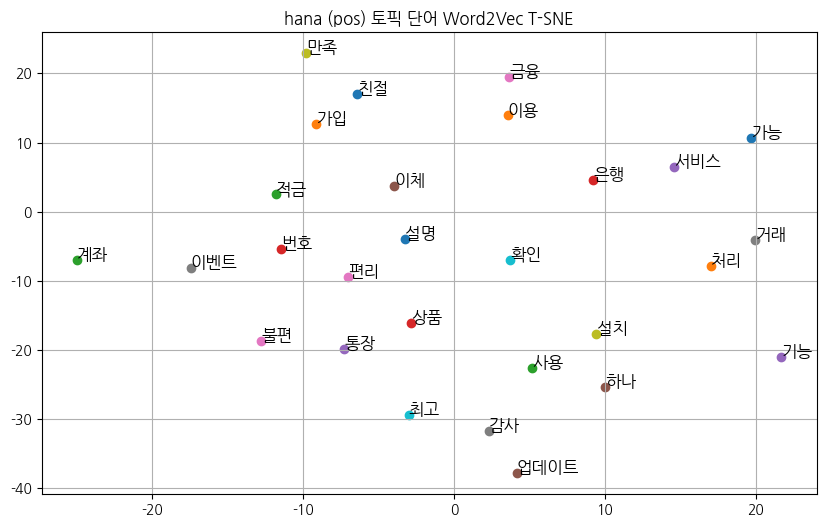

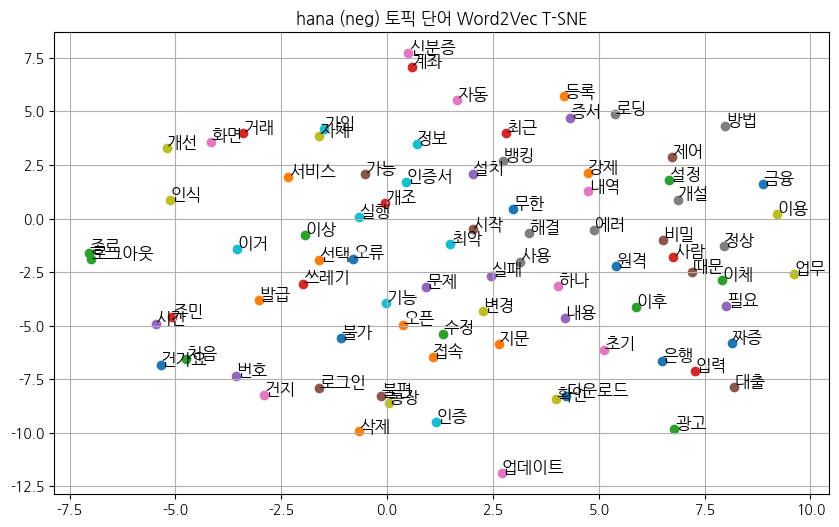

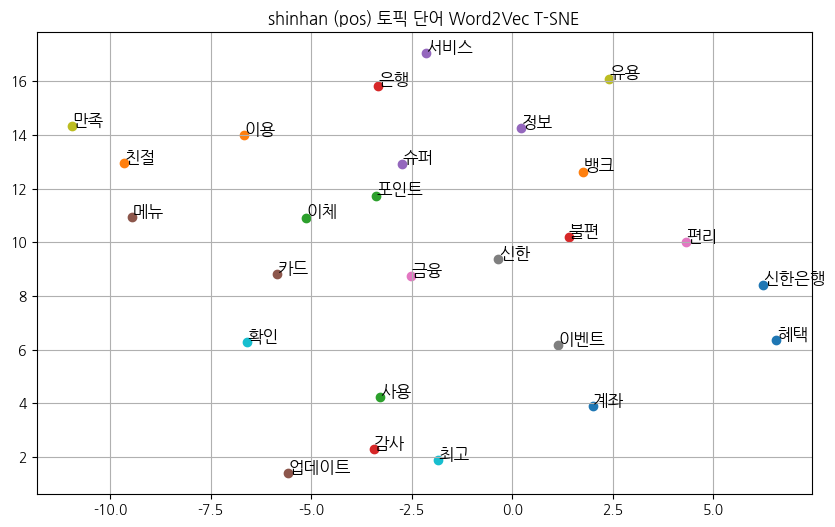

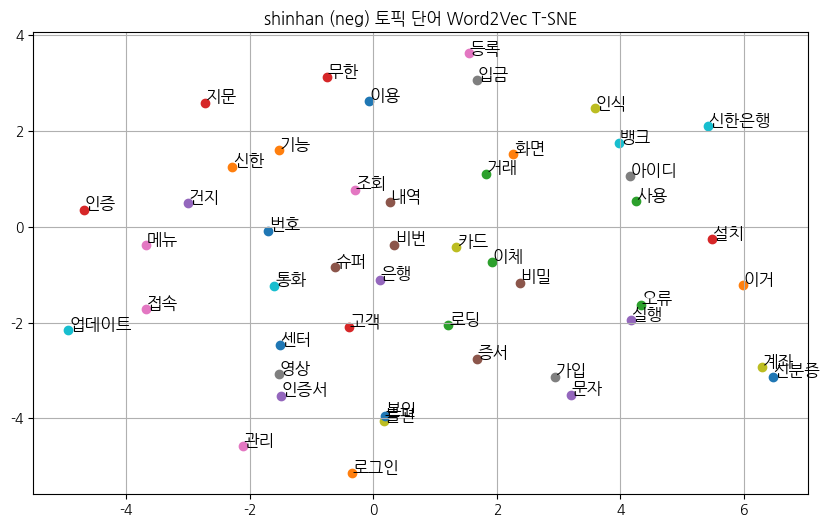

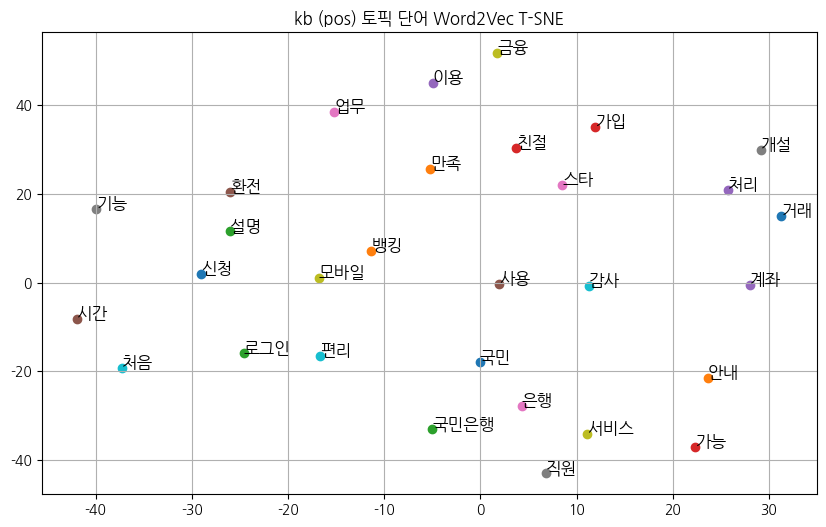

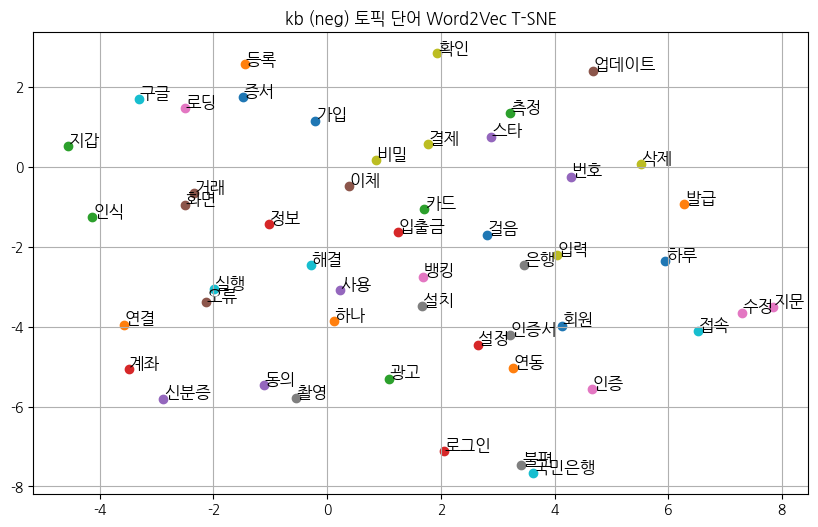

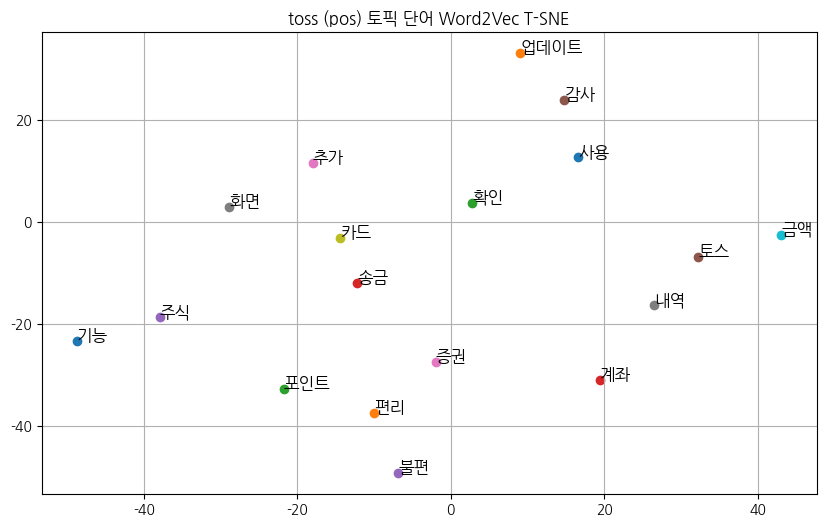

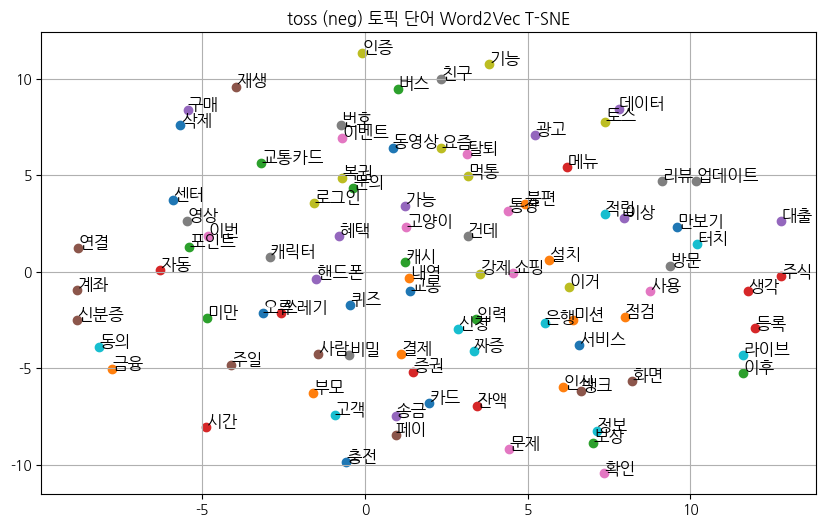

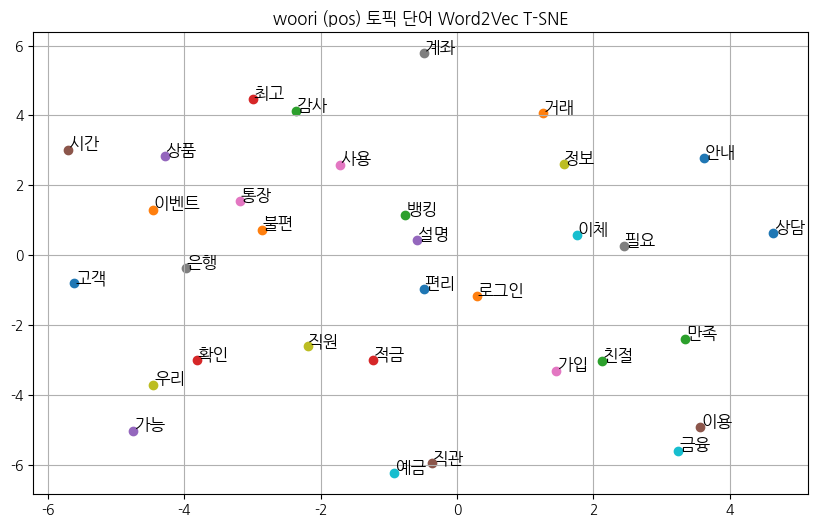

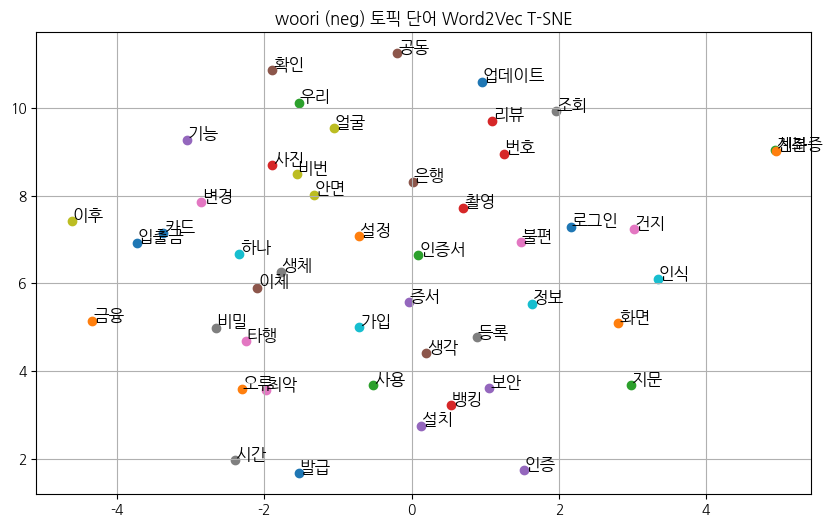

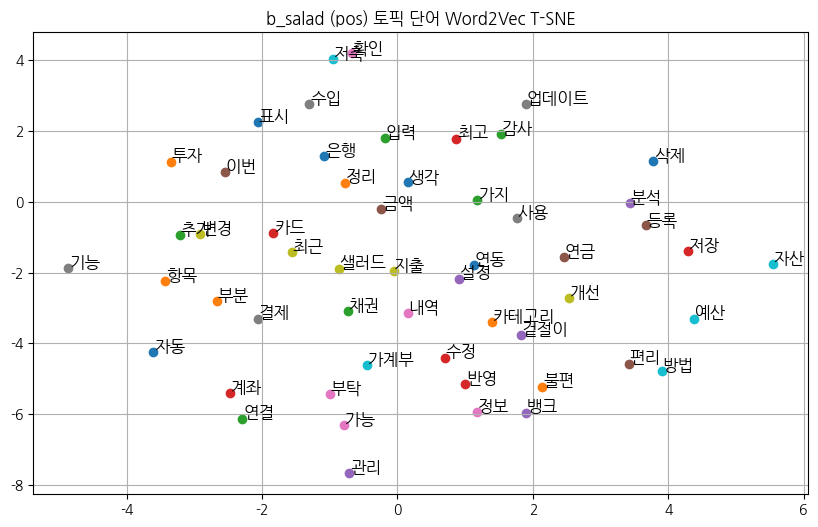

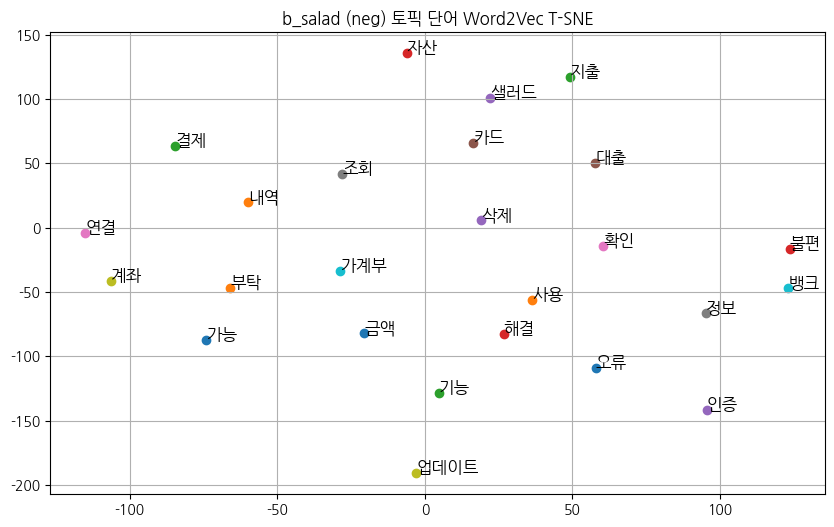

In [63]:
for (bank_eng, senti), all_topic_words in topic_words_map.items():
    valid_words = [w for w in all_topic_words if w in w2v_model.wv]
    print(f"\n[{bank_eng}]({senti}) 토픽단어 {len(all_topic_words)}개 | w2v포함 {len(valid_words)}개")
    
    vectors = np.array([w2v_model.wv[w] for w in valid_words])
    
    #perplexity 자동조절
    tsne_perplexity = min(15, max(5, (len(valid_words) -1) // 3))
    tsne_perplexity = min(tsne_perplexity, len(valid_words) -1)
    if tsne_perplexity < 2:
        tsne_perplexity = 2
    print(f"T-SNE perplexity = {tsne_perplexity}")
    
    tsne = TSNE(
            n_components=2,
            random_state=0,
            perplexity=tsne_perplexity,
            init='pca',
            learning_rate="auto"
            )
    reduced_vecs = tsne.fit_transform(vectors)
    
    plt.figure(figsize=(10,6))
    for i, word in enumerate(valid_words):
        x, y = reduced_vecs[i]
        plt.scatter(x, y)
        plt.text(x + 0.01, y+0.01, word, fontsize=12)
    plt.title(f"{bank_eng} ({senti}) 토픽 단어 Word2Vec T-SNE")
    plt.grid(True)

# 텐서보드로 Word2Vec, T-SNE 를 3차원으로 시각화 하기

In [64]:
# !pip install tensorflow

In [65]:
import os
import numpy as np
import tensorflow as tf
from tensorboard.plugins import projector
from gensim.models import Word2Vec

# =============================================================================
# 유틸: 폴더/파일명에 쓸 수 있도록 문자열 안전 변환
# =============================================================================
def safe_name(s: str) -> str:
    return ''.join(c if c.isalnum() else '_' for c in str(s))

# =============================================================================
# MeCab tokenizer (기존과 동일 기준)
# =============================================================================
def mecab_tokenizer(text):
    return [w for w in mecab.morphs(str(text)) if len(w) > 1]

def tokenize_docs(texts):
    tokenized = []
    for t in texts:
        toks = mecab_tokenizer(t)
        if len(toks) >= 2:
            tokenized.append(toks)
    return tokenized

# =============================================================================
# TensorBoard 로그 루트
# =============================================================================
LOG_ROOT = os.path.join(os.getcwd(), "tensorboard_logs")
os.makedirs(LOG_ROOT, exist_ok=True)

print("--- TensorBoard Embedding Projector 로그 생성 시작 ---")
print(f"LOG_ROOT = {LOG_ROOT}")

# =============================================================================
# 1) Word2Vec 준비: 이미 w2v_model이 있으면 재학습 안 함
# =============================================================================
if 'w2v_model' not in globals() or w2v_model is None:
    print("w2v_model이 없어 train_df로 Word2Vec을 1회 학습합니다...")

    if 'train_df' in globals() and hasattr(train_df, "columns") and '사용자리뷰' in train_df.columns:
        all_reviews = train_df['사용자리뷰'].dropna().astype(str).tolist()
        all_tokenized = tokenize_docs(all_reviews)

        if len(all_tokenized) < 5:
            raise ValueError("Word2Vec 학습용 유효 토큰 문서가 너무 적습니다. (5 미만)")
        w2v_model = Word2Vec(
            sentences=all_tokenized,
            vector_size=100,
            window=5,
            min_count=2,
            workers=4,
            sg=1,
            seed=42
        )
        print(f"✅ Word2Vec 학습 완료 | 전체 리뷰={len(all_reviews)} | 유효 토큰 문서={len(all_tokenized)}")
    else:
        raise ValueError("'train_df' 또는 '사용자리뷰' 컬럼이 없어 Word2Vec을 준비할 수 없습니다.")
else:
    print("✅ 기존 w2v_model을 사용합니다. (재학습 없음)")

# =============================================================================
# 2) topic_words_map 필요: (bank_eng, senti) -> set(words)
# =============================================================================
if 'topic_words_map' not in globals() or not isinstance(topic_words_map, dict) or len(topic_words_map) == 0:
    raise ValueError("topic_words_map이 없습니다. (토픽 모델링 단계에서 토픽 단어 set 저장 필요)")

# =============================================================================
# 3) Projector 로그 생성 (LDA/TSNE 등 재실행 없음)
# =============================================================================
for (bank_eng, senti), words_set in topic_words_map.items():
    # topic_words_map 값이 set이 아니어도 list로 캐스팅 가능
    topic_words = list(words_set)

    # Word2Vec에 있는 단어만
    filtered_words = [w for w in topic_words if w in w2v_model.wv]

    print(f"\n[{bank_eng}] ({senti}) topic_words={len(topic_words)} | in_w2v={len(filtered_words)}")

    if len(filtered_words) < 3:
        print("   ⚠ Word2Vec 포함 단어가 3개 미만 -> 스킵")
        continue

    vectors = np.array([w2v_model.wv[w] for w in filtered_words], dtype=np.float32)

    # (A) 로그 디렉토리
    log_dir = os.path.join(LOG_ROOT, f"embedding_{safe_name(bank_eng)}_{safe_name(senti)}")
    os.makedirs(log_dir, exist_ok=True)

    # (B) 임베딩 변수 + 체크포인트 저장
    embedding_var = tf.Variable(vectors, name="word_embeddings")
    checkpoint = tf.train.Checkpoint(word_embeddings=embedding_var)
    checkpoint_prefix = os.path.join(log_dir, "embedding.ckpt")
    checkpoint.save(checkpoint_prefix)

    # (C) metadata.tsv 저장
    metadata_path = os.path.join(log_dir, "metadata.tsv")
    with open(metadata_path, "w", encoding="utf-8") as f:
        f.write("word\tbank\tsentiment\n")
        for w in filtered_words:
            f.write(f"{w}\t{bank_eng}\t{senti}\n")

    # (D) projector config
    config = projector.ProjectorConfig()
    emb = config.embeddings.add()
    emb.tensor_name = embedding_var.name   # e.g., "word_embeddings:0"
    emb.metadata_path = "metadata.tsv"

    projector.visualize_embeddings(log_dir, config)

    print(f"   ✅ Projector 로그 생성 완료: {log_dir}")

print("\n--- 완료 ---")
print(f"TensorBoard 실행 예: tensorboard --logdir \"{LOG_ROOT}\"")

2026-03-05 14:48:56.639014: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-05 14:48:56.687686: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-05 14:48:58.098837: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


--- TensorBoard Embedding Projector 로그 생성 시작 ---
LOG_ROOT = /mnt/c/fintech4/06Machine_Learning_Deep_Learning/tensorboard_logs
✅ 기존 w2v_model을 사용합니다. (재학습 없음)

[hana] (pos) topic_words=28 | in_w2v=28
   ✅ Projector 로그 생성 완료: /mnt/c/fintech4/06Machine_Learning_Deep_Learning/tensorboard_logs/embedding_hana_pos

[hana] (neg) topic_words=83 | in_w2v=83
   ✅ Projector 로그 생성 완료: /mnt/c/fintech4/06Machine_Learning_Deep_Learning/tensorboard_logs/embedding_hana_neg

[shinhan] (pos) topic_words=26 | in_w2v=26
   ✅ Projector 로그 생성 완료: /mnt/c/fintech4/06Machine_Learning_Deep_Learning/tensorboard_logs/embedding_shinhan_pos

[shinhan] (neg) topic_words=47 | in_w2v=47


2026-03-05 14:48:58.478788: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


   ✅ Projector 로그 생성 완료: /mnt/c/fintech4/06Machine_Learning_Deep_Learning/tensorboard_logs/embedding_shinhan_neg

[kb] (pos) topic_words=30 | in_w2v=30
   ✅ Projector 로그 생성 완료: /mnt/c/fintech4/06Machine_Learning_Deep_Learning/tensorboard_logs/embedding_kb_pos

[kb] (neg) topic_words=50 | in_w2v=50
   ✅ Projector 로그 생성 완료: /mnt/c/fintech4/06Machine_Learning_Deep_Learning/tensorboard_logs/embedding_kb_neg

[toss] (pos) topic_words=18 | in_w2v=18
   ✅ Projector 로그 생성 완료: /mnt/c/fintech4/06Machine_Learning_Deep_Learning/tensorboard_logs/embedding_toss_pos

[toss] (neg) topic_words=91 | in_w2v=91
   ✅ Projector 로그 생성 완료: /mnt/c/fintech4/06Machine_Learning_Deep_Learning/tensorboard_logs/embedding_toss_neg

[woori] (pos) topic_words=33 | in_w2v=33
   ✅ Projector 로그 생성 완료: /mnt/c/fintech4/06Machine_Learning_Deep_Learning/tensorboard_logs/embedding_woori_pos

[woori] (neg) topic_words=48 | in_w2v=48
   ✅ Projector 로그 생성 완료: /mnt/c/fintech4/06Machine_Learning_Deep_Learning/tensorboard_logs/embed

#  TensorBoard Embedding Projector 포함 + 2D t-SNE

* Projector 탭 이동: 우측 상단의 탭에서 **'Projector'**를 선택합니다.
* 시각화 확인:
  * 데이터가 로드되면 3D 공간에 단어들이 점으로 표시됩니다.
  * 왼쪽 패널에서 'Run' 드롭다운을 열어 shinhan, woori 등 분석한 은행별 데이터를 선택할 수 있습니다.
  * 왼쪽 'Dimensions'에서 t-SNE를 선택하고, 3D로 설정합니다.
  * 이제 마우스로 3D 공간을 돌려보거나 확대/축소하며 단어들의 군집을 인터랙티브하게 탐색할 수 있습니다.

In [66]:
# TensorBoard 매직 명령어 로드
%load_ext tensorboard

#'hana' 은행의 로그 디렉토리를 구체적으로 지정하여 실행
%tensorboard --logdir ./tensorboard_logs/embedding_kb_neg

#왼쪽 DATA 항목에서 load 클릭 후 metadata.tsv를 로드해야 단어가 보임

Reusing TensorBoard on port 6008 (pid 38719), started 0:38:57 ago. (Use '!kill 38719' to kill it.)